In [19]:
import matplotlib.pyplot as plt
import cmasher as cmr
import numpy as np
import h5py
import pickle
import requests
import os.path
from astropy.cosmology import LambdaCDM
from unyt import Myr, K, Gyr, mp, kpc, kb, Angstrom, deg, cm, Msun, Mpc
from synthesizer.kernel_functions import Kernel
from synthesizer.particle import Stars, Gas, Galaxy, BlackHoles
from synthesizer.grid import Grid
from synthesizer.emission_models import PacmanEmission, IntrinsicEmission, UnifiedAGN, EmissionModel, AttenuatedEmission, DustEmission
from synthesizer.emission_models.attenuation import GrainModels
from synthesizer.emission_models import Blackbody, Greybody
from synthesizer.filters import FilterCollection
from synthesizer.emissions.line_ratios import get_diagram_labels
from scipy.ndimage import gaussian_filter


### Define simulation, snapshot, and object

In [20]:
baseUrl = 'http://www.tng-project.org/api/TNG100-1/'
redshift = 2.0
id = '5591'

### Illustris API key - **MUST BE REPLACED**

In [21]:
api_key = "c37483fea84b70f4ad9f777c38357ea0"

### Get properties of the simulation

In [22]:

headers = {"api-key": api_key}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    return r

simulation = get(baseUrl)

In [23]:
for k, v in simulation.items():
    print(f'{k}: {v}')

name: TNG100-1
description: Main high-resolution IllustrisTNG100 run including the full TNG physics model.
name_alt: L75n1820TNG
boxsize: 75000.0
z_start: 127.0
z_final: 0.0
cosmology: Planck2015
omega_0: 0.3089
omega_L: 0.6911
omega_B: 0.0486
hubble: 0.6774
physics_model: Fiducial TNG Model
has_cooling: True
has_starformation: True
has_winds: True
has_blackholes: True
mass_gas: 9.43946e-05
mass_dm: 0.000505574296436975
softening_dm_comoving: 1.0
softening_stars_comoving: 1.0
softening_blackholes_comoving: 1.0
softening_gas_comoving: 1.0
softening_dm_max_phys: 0.5
softening_stars_max_phys: 0.5
softening_blackholes_max_phys: 1.0
softening_gas_max_phys: 0.5
softening_gas_factor: 2.5
softening_gas_comoving_min: 0.125
num_dm: 6028568000
num_tr_mc: 6028568000
num_tr_vel: 0
longids: True
is_uniform: True
is_zoom: False
is_subbox: False
num_files_snapshot: 448
num_files_groupcat: 448
num_files_rockstar: 0
num_files_lhalotree: 120
num_files_sublink: 20
num_files_ctrees: 0
filesize_lhalotree: 2

### Define cosmology

Extracts cosmological parameters and creates `astropy.cosmology` object.

In [24]:
h = simulation['hubble']
Om0 = simulation['omega_0']
Ode0 = simulation['omega_L']
H0 = h * 100 
Ob0 = simulation['omega_B']

cosmo = LambdaCDM(Om0=Om0, Ode0=Ode0, H0=H0, Ob0=Ob0)

In [25]:
# create a dictionary of snapshots and redshifts (useful later)
snapshots = get(simulation['snapshots'])
snapshot_redshifts = {snapshot['number']: snapshot['redshift'] for snapshot in snapshots}


### Download data

This creates a HDF5 file which is used later.

In [26]:
# the quantities that we want to grab: the coordinates, metallicity, age, and initial mass of all the star particles
params = {
    'stars':'Coordinates,GFM_Metallicity,GFM_StellarFormationTime,GFM_InitialMass',
    'gas': 'Coordinates,GFM_Metallicity,SubfindHsml,Masses,InternalEnergy,ElectronAbundance',
    'bhs': 'Coordinates,BH_Mass,BH_Mdot,Masses',
    }

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open('data/'+filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

# the data url for the object of interest
url = f"{baseUrl}/snapshots/z={str(redshift)}/subhalos/{str(id)}"

# Download the subhalo properties for the specific galaxy and save them as pickle file
subhalo_properties_filename = f'data/subhalo_properties_{id}.pck'
if not os.path.isfile(subhalo_properties_filename):
    subhalo_properties = get(url) # get json response of subhalo properties
    pickle.dump(subhalo_properties, open(subhalo_properties_filename,'wb'))
else:
    subhalo_properties = pickle.load(open(f'data/subhalo_properties_{id}.pck','rb'))

# Get snapshot redshift
snapshot_redshift = snapshot_redshifts[subhalo_properties['snap']]
print(f'snapshot redshift: {snapshot_redshift}')

# Download the HDF5 cutout for the galaxy if it hasn't already been downloaded
cutout_filename = f'data/cutout_{id}.hdf5'
if not os.path.isfile(cutout_filename):
    get(url + "/cutout.hdf5", params) # get and save HDF5 cutout file



snapshot redshift: 2.00202813925285


### Create `Galaxy` object

After downloading the data we need to create a synthesizer galaxy object.


In [27]:
with h5py.File(cutout_filename) as f:

    # GFM_StellarFormationTime is the scale factor when the  
    formation_scale_factor = f['PartType4']['GFM_StellarFormationTime'][()]
    formation_redshift = 1/formation_scale_factor - 1.0
    
    # only select star particles that make sense
    s = formation_redshift >= snapshot_redshift
    formation_redshift = formation_redshift[s]

    # calculate the ages of star particle and record as unyt quantity
    ages = (cosmo.age(z=snapshot_redshift)-cosmo.age(formation_redshift)).to('Myr').value * Myr

    # convert units of initial masses
    initial_masses = f['PartType4']['GFM_InitialMass'][s] * Msun * 1E10 / h 

    # define the coorindates of the star particles 
    x = f['PartType4']['Coordinates'][s,0] 
    y = f['PartType4']['Coordinates'][s,1] 
    z = f['PartType4']['Coordinates'][s,2] 

    # convert coordinates to physical and change the units
    coordinates = np.array([x,y,z]).T / (1+snapshot_redshift) / h / 1000 * Mpc

    # create a stars object
    stars = Stars(
        ages=ages,
        initial_masses=initial_masses,
        metallicities=f['PartType4']['GFM_Metallicity'][s],
        coordinates=coordinates,
        )
    
    # gas temperature
    X_H = 0.76
    mu = 4 * mp / (1+4*X_H+4*X_H*f['PartType0']['ElectronAbundance'][:])
    gamma = 5/3
    UnitMass = 1E10 * Msun
    UnitTime = 1 * Gyr
    UnitLength = 1 * kpc
    UnitEnergy = UnitMass * UnitLength**2 / UnitTime**2
    temp = (gamma - 1.) * (f['PartType0']['InternalEnergy'][:] / kb) * (UnitEnergy/UnitMass) * mu
    print(np.min(temp), np.median(temp), np.max(temp))

    selection = temp < 1E6 * K


    # define the coorindates of the gas particles 
    x = f['PartType0']['Coordinates'][selection,0] 
    y = f['PartType0']['Coordinates'][selection,1] 
    z = f['PartType0']['Coordinates'][selection,2] 

    # convert coordinates to physical and change the units
    coordinates = np.array([x,y,z]).T  / (1 + snapshot_redshift) / h / 1000 * Mpc

    # create a gas object
    gas = Gas(
        masses=f['PartType0']['Masses'][selection] * 1E10 / h * Msun,
        metallicities=f['PartType0']['GFM_Metallicity'][selection],
        smoothing_lengths=f['PartType0']['SubfindHsml'][selection] / (1 + snapshot_redshift) / h / 1000 * Mpc,
        coordinates=coordinates,
        )
    

    # define the coorindates of the gas particles 
    x = f['PartType5']['Coordinates'][:,0] 
    y = f['PartType5']['Coordinates'][:,1] 
    z = f['PartType5']['Coordinates'][:,2] 

    # convert coordinates to physical and change the units
    coordinates = np.array([x,y,z]).T  / (1 + snapshot_redshift) / h / 1000 * Mpc

    # create a gas object
    blackholes = BlackHoles(
        masses=f['PartType5']['BH_Mass'][:] * 1E10 / h * Msun,
        accretion_rates=f['PartType5']['BH_Mdot'][:] * 1E10 * Msun / Gyr,
        coordinates=coordinates,
        )

centre = np.array([subhalo_properties['pos_x'],
                subhalo_properties['pos_y'],
                subhalo_properties['pos_z'],
                ]) * Mpc / (1 + snapshot_redshift) / h / 1000 ,

# initialise the galaxy object
galaxy = Galaxy(stars=stars, gas=gas, black_holes=blackholes, centre=centre)

12851.399647344562 K 112745.03838866507 K 7560596.586264868 K


/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_5757/885897617.py:56: RuntimeWarning: 
Neither dust mass nor dust to metal ratio provided. Assuming dust to metal ratio
= 0.3
  gas = Gas(
/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_5757/885897617.py:85: RuntimeWarning: 
Current mass of stars not provided, setting stellar_mass_weighted_age to `None`
  galaxy = Galaxy(stars=stars, gas=gas, black_holes=blackholes, centre=centre)
/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_5757/885897617.py:85: RuntimeWarning: 
Star forming gas particle mask not provided, setting sf_gas_mass and
sf_gas_metallicity to `None`
  galaxy = Galaxy(stars=stars, gas=gas, black_holes=blackholes, centre=centre)


### Dust attenuation

Now calculate the line-of-sight dust attenuation.

In [28]:
# calculate LOS dust attenuation
kappa = 0.3
kernel = Kernel()
galaxy.get_stellar_los_tau_v(kappa=kappa, kernel=kernel.get_kernel(), force_loop=True)
galaxy.get_black_hole_los_tau_v(kappa=kappa, kernel=kernel.get_kernel(), force_loop=True)

array([4.62450617])

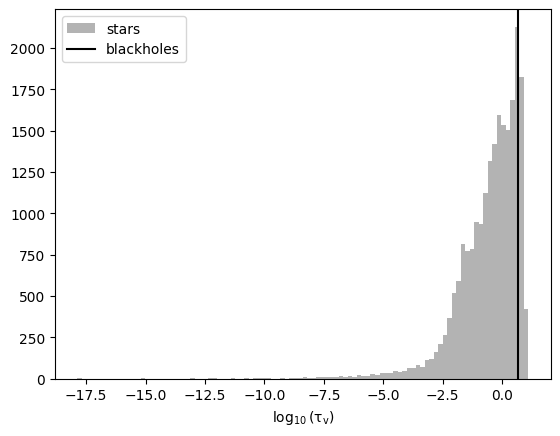

In [29]:
# plot the distribution of optical depths for star particles and add a line for the BH
tauv = galaxy.stars.tau_v
tauv = tauv[tauv>0.0]

plt.hist(np.log10(tauv), bins=100, label='stars', color='0.7')
plt.axvline(np.log10(galaxy.black_holes.tau_v[0]), c='k', label='blackholes')
plt.xlabel(r'$\rm \log_{10}(\tau_v)$')

plt.legend()
plt.show()

### Initialise grids

In [30]:
grid_dir = '/Users/sw376/Dropbox/Research/data/synthesizer/grids/'

wavelength_range = [1001, 6999]
new_lam = np.linspace(*wavelength_range, 600) * Angstrom

stellar_grid =  Grid(
    grid_name='bpass-2.2.1-bin_chabrier03-0.1,300.0_cloudy-c23.01-sps', 
    grid_dir=grid_dir,
    new_lam=new_lam,
    )

nlr_grid = Grid(
    grid_name='qsosed-test_cloudy-c23.01-nlr-test', 
    grid_dir=grid_dir,
    new_lam=new_lam
    )

blr_grid = Grid(
    grid_name='qsosed-test_cloudy-c23.01-blr-test', 
    grid_dir=grid_dir,
    new_lam=new_lam
    )

/var/folders/yq/3hbmb92x4dl_lmcnb1c71h880000gp/T/ipykernel_5757/4229847989.py:6: RuntimeWarning: 
The following lines are outside the wavelength range of the grid: [np.str_('Ar 3
7135.79A'), np.str_('Fe 2 7155.17A'), np.str_('Fe 2 7172.00A'), np.str_('Ca 2
7291.47A'), np.str_('Ca 2 7323.89A'), np.str_('Ni 2 7377.83A'), np.str_('Fe 2
7388.17A'), np.str_('Ni 2 7411.61A'), np.str_('Fe 2 7452.56A'), np.str_('Ar 3
7751.11A'), np.str_('O 1 8446.25A'), np.str_('O 1 8446.36A'), np.str_('O 1
8446.76A'), np.str_('Cl 2 8578.70A'), np.str_('Fe 2 8616.95A'), np.str_('Fe 2
8891.93A'), np.str_('Fe 2 9051.95A'), np.str_('S 3 9068.62A'), np.str_('Fe 2
9226.63A'), np.str_('H 1 9229.02A'), np.str_('Fe 2 9267.56A'), np.str_('Fe 2
9399.04A'), np.str_('Fe 2 9470.94A'), np.str_('S 3 9530.62A'), np.str_('H 1
9545.97A'), np.str_('H 1 1.00494m'), np.str_('S 2 1.02867m'), np.str_('S 2
1.03205m'), np.str_('S 2 1.03364m'), np.str_('He 1 1.08291m'), np.str_('He 1
1.08303m'), np.str_('H 1 1.09381m'), np.str_('O 1 1.

In [31]:
print(stellar_grid)

for ax in stellar_grid.axes:
    print(ax, stellar_grid.axes_values[ax])

+---------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                                       GRID                                                                        |
+-----------------------------+---------------------------------------------------------------------------------------------------------------------+
| Attribute                   | Value                                                                                                               |
+-----------------------------+---------------------------------------------------------------------------------------------------------------------+
| grid_dir                    | '/Users/sw376/Dropbox/Research/data/synthesizer/grids/'                                                             |
+-----------------------------+---------------------------------------------------------------------

In [32]:
print(nlr_grid)

for ax in nlr_grid.axes:
    print(ax, nlr_grid.axes_values[ax])

+-------------------------------------------------------------------------------------------------------------------------------+
|                                                             GRID                                                              |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| Attribute                   | Value                                                                                           |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| grid_dir                    | '/Users/sw376/Dropbox/Research/data/synthesizer/grids/'                                         |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| grid_name                   | 'qsosed-test_cloudy-c23.01-nlr-test'                      

In [33]:
print(blr_grid)

for ax in blr_grid.axes:
    print(ax, blr_grid.axes_values[ax])

+-------------------------------------------------------------------------------------------------------------------------------+
|                                                             GRID                                                              |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| Attribute                   | Value                                                                                           |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| grid_dir                    | '/Users/sw376/Dropbox/Research/data/synthesizer/grids/'                                         |
+-----------------------------+-------------------------------------------------------------------------------------------------+
| grid_name                   | 'qsosed-test_cloudy-c23.01-blr-test'                      

### Emission model

In [35]:
# specify a power-law dust curve

stellar_particle_emission_model = PacmanEmission(
    grid=stellar_grid, 
    dust_curve=GrainModels(model="D03", submodel="MWRV31"),
    dust_emission=Greybody(50 * K, emissivity=2.0),
    per_particle=True,
    escape_fraction=0.0,
    )

# relabel the stellar spectra
stellar_particle_emission_model.add_label_prefix("stellar")

blackhole_particle_emission_model = UnifiedAGN(
    nlr_grid,
    blr_grid,
    torus_emission_model=Greybody(1000 * K, 1.5),
    disc_transmission='blr',
    covering_fraction_nlr=0.1,
    covering_fraction_blr=0.3,
    metallicity=0.001,
    ionisation_parameter_nlr=0.01,
    hydrogen_density_nlr=1e4 * cm**-3,
    ionisation_parameter_blr=0.01,
    hydrogen_density_blr=1e10 * cm**-3,
    column_density=23.,
    per_particle=True,
    diffuse_dust_curve=GrainModels(model="D03", submodel="MWRV31"),
    diffuse_dust_emission_model=Greybody(100 * K, emissivity=2.0),
)

# relabel the agn spectra
blackhole_particle_emission_model.add_label_prefix("agn")

total_emission_model = EmissionModel(
    label="total",
    combine=(blackhole_particle_emission_model, stellar_particle_emission_model),
    emitter="galaxy",
)

### Generate spectra

In [36]:
spectra = galaxy.get_spectra(total_emission_model)

/Users/sw376/Dropbox/Research/projects/synthesizer_projects/agn-workshop/venv/lib/python3.10/site-packages/unyt/array.py:1832: RuntimeWarning: overflow encountered in exp
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)
/Users/sw376/Dropbox/Research/projects/synthesizer_projects/agn-workshop/venv/lib/python3.10/site-packages/unyt/array.py:1972: RuntimeWarning: overflow encountered in multiply
  out_arr = func(


(<Figure size 350x500 with 1 Axes>,
 <Axes: xlabel='$\\lambda/[\\mathrm{\\AA}]$', ylabel='$L_{\\nu}/[\\mathrm{\\rm{erg} \\ / \\ \\rm{Hz \\cdot \\rm{s}}}]$'>)

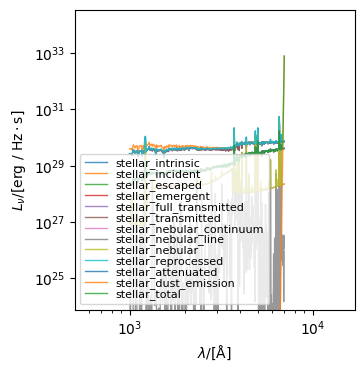

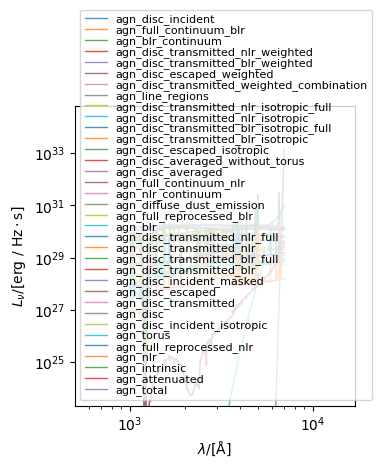

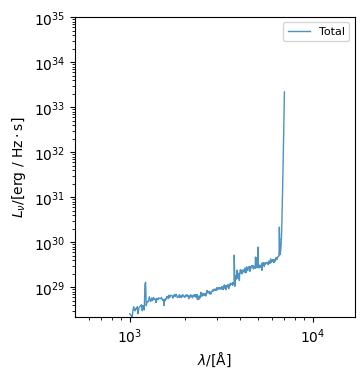

In [39]:
galaxy.stars.plot_spectra()
galaxy.black_holes.plot_spectra()
galaxy.plot_spectra()

